In [2]:
#  Core Libraries
!pip install -q numpy pandas matplotlib tqdm

#  Audio Processing
!pip install -q librosa soundfile

#  Machine Learning + DL
!pip install -q tensorflow scikit-learn keras-tuner


In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm import tqdm


# === Constants ===
SR = 22050
N_MELS = 256
FMAX = 8000
FIXED_TIME_STEPS = 150
SEED = 42
np.random.seed(SEED)

# === Paths ===
BASE_DIR = "/kaggle/working/"
AUDIO_DIR = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Train"
CSV_PATH = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Train.csv"
CACHE_DIR = os.path.join(BASE_DIR, "mel_cache")

# Make cache dir
os.makedirs(CACHE_DIR, exist_ok=True)

# === Load metadata
df = pd.read_csv(CSV_PATH)
df["filepath"] = df["file_name"].apply(lambda x: os.path.join(AUDIO_DIR, x))
df.head()


,file_name,classID,filepath
0,data_0.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...
1,data_1.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...
2,data_2.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...
3,data_3.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...
4,data_4.wav,6,/kaggle/input/yldz-teknik-proje-1-train-datase...


In [3]:
def mel_cache_audio(df, filepath_col="filepath", add_to_df=True):
    """
    Caches mel spectrograms for each file in the dataframe.
    Skips if already cached. Optionally adds 'mel_path' column to df.
    
    Enhancements:
    - Logs with tqdm.write() to avoid breaking progress bar
    - Checks if file exists before attempting to load
    - Verifies sample rate matches SR
    - Optionally updates DataFrame with path to cached mel file
    """
    created, skipped, failed = 0, 0, 0
    mel_paths = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=" Caching mel spectrograms"):
        wav_path = row[filepath_col]
        out_path = os.path.join(CACHE_DIR, os.path.basename(wav_path).replace(".wav", "_mel.npy"))
        mel_paths.append(out_path)

        # Skip if already cached
        if os.path.exists(out_path):
            skipped += 1
            continue

        # Check if file exists
        if not os.path.exists(wav_path):
            tqdm.write(f"[ Missing] {wav_path}")
            failed += 1
            continue

        try:
            y, sr = librosa.load(wav_path, sr=SR)
            if sr != SR:
                tqdm.write(f"[ SR mismatch] {wav_path} → sr={sr}, expected {SR}")
            
            # Generate mel spectrogram
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
            mel_db = librosa.util.fix_length(mel_db, size=FIXED_TIME_STEPS, axis=1)
            mel_db = np.expand_dims(mel_db, axis=-1)

            np.save(out_path, mel_db)
            created += 1

        except Exception as e:
            tqdm.write(f"[ Error] Skipping {wav_path}: {e}")
            failed += 1

    tqdm.write(f"\n Done. Created: {created}, Skipped: {skipped}, Failed: {failed}")

    if add_to_df:
        df["mel_path"] = mel_paths

    return df if add_to_df else None


In [4]:
df = mel_cache_audio(df)
df.head()

 Caching mel spectrograms: 100%|██████████| 7057/7057 [00:00<00:00, 21740.88it/s]


 Done. Created: 0, Skipped: 7057, Failed: 0


,file_name,classID,filepath,mel_path
0,data_0.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_0_mel.npy
1,data_1.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_1_mel.npy
2,data_2.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_2_mel.npy
3,data_3.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_3_mel.npy
4,data_4.wav,6,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_4_mel.npy


In [6]:
def inspect_cached_mels(df, n=5):
    print(f"\n📂 Inspecting {n} random cached mels:")
    sample_files = df.sample(n, random_state=np.random.randint(9999))
    
    for _, row in sample_files.iterrows():
        mel_path = os.path.join(
            CACHE_DIR, os.path.basename(row["filepath"]).replace(".wav", "_mel.npy")
        )
        try:
            mel = np.load(mel_path)
            print(f"✅ {mel_path}")
            print(f"  - Shape     : {mel.shape}")
            print(f"  - Min/Max   : {mel.min():.3f} / {mel.max():.3f}")
            print(f"  - Nonzero % : {np.count_nonzero(mel) / mel.size * 100:.2f}%")
        except Exception as e:
            print(f"❌ {mel_path} failed to load: {e}")


In [7]:
inspect_cached_mels(df)


📂 Inspecting 5 random cached mels:
✅ /kaggle/working/mel_cache/data_4218_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
✅ /kaggle/working/mel_cache/data_2661_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
✅ /kaggle/working/mel_cache/data_318_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
✅ /kaggle/working/mel_cache/data_6731_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
✅ /kaggle/working/mel_cache/data_5493_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%


In [5]:
import tensorflow as tf
import tensorflow_probability as tfp

@tf.function
def tf_augment_mel(mel):
    """Apply stronger data augmentation to a mel spectrogram (shape: [H, W, 1])"""
    shape = tf.shape(mel)
    height, width = shape[0], shape[1]
    x = mel

    # === Time Stretch ===
    if tf.random.uniform([]) < 0.5:
        stretch_factor = tf.random.uniform([], 0.8, 1.2)
        new_width = tf.cast(tf.cast(width, tf.float32) * stretch_factor, tf.int32)
        x = tf.image.resize(x, [height, new_width])
        x = tf.image.resize(x, [height, width])

    # === Time Mask ===
    if tf.random.uniform([]) < 0.7:
        mask_t = tf.cast(0.15 * tf.cast(width, tf.float32), tf.int32)
        t0 = tf.random.uniform([], 0, width - mask_t, dtype=tf.int32)
        time_mask = tf.pad(tf.ones([height, mask_t, 1]), [[0, 0], [t0, width - t0 - mask_t], [0, 0]])
        x = x * (1.0 - time_mask)

    # === Frequency Mask ===
    if tf.random.uniform([]) < 0.7:
        mask_f = tf.cast(0.15 * tf.cast(height, tf.float32), tf.int32)
        f0 = tf.random.uniform([], 0, height - mask_f, dtype=tf.int32)
        freq_mask = tf.pad(tf.ones([mask_f, width, 1]), [[f0, height - f0 - mask_f], [0, 0], [0, 0]])
        x = x * (1.0 - freq_mask)

    # === Add Gaussian Noise ===
    if tf.random.uniform([]) < 0.5:
        noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=0.01)
        x = x + noise

    # === Frequency Shift (roll vertically) ===
    if tf.random.uniform([]) < 0.5:
        shift_bins = tf.random.uniform([], -4, 4, dtype=tf.int32)
        x = tf.roll(x, shift=shift_bins, axis=0)

    # === Volume Jitter (brightness / loudness) ===
    if tf.random.uniform([]) < 0.8:
        volume_scale = tf.random.uniform([], 0.8, 1.2)
        x = x * volume_scale

    # === Soft Clipping Simulation (tanh) ===
    if tf.random.uniform([]) < 0.3:
        # Apply tanh compression and re-normalize to [0, 1]
        x = tf.math.tanh(x)
        x = (x + 1.0) / 2.0
        
    # === Normalize ===
    x_min, x_max = tf.reduce_min(x), tf.reduce_max(x)
    x = (x - x_min) / (x_max - x_min + 1e-6)

    return x




def mixup_batch(images, labels, num_classes, alpha=0.4):
    """
    Applies Mixup augmentation to a batch of images and labels.
    
    Args:
        images: Tensor of shape (B, H, W, C)
        labels: Tensor of shape (B,) — sparse integer labels
        num_classes: Total number of classes
        alpha: Beta distribution parameter for mixing strength

    Returns:
        Tuple of (mixed_images, mixed_labels) where labels are soft one-hot vectors.
    """
    batch_size = tf.shape(images)[0]

    # Sample lambda from symmetric Beta(α, α)
    lambda_val = tfp.distributions.Beta(alpha, alpha).sample([batch_size])
    lambda_val = tf.maximum(lambda_val, 1.0 - lambda_val)  # enforce stronger mixing (λ ≥ 0.5)

    # One-hot encode original labels
    labels = tf.cast(labels, tf.int32)  # Fixed
    labels_onehot = tf.one_hot(labels, depth=num_classes)


    # Shuffle batch
    indices = tf.random.shuffle(tf.range(batch_size))
    shuffled_images = tf.gather(images, indices)
    shuffled_labels = tf.gather(labels_onehot, indices)

    # Reshape lambdas
    lambda_x = tf.reshape(lambda_val, [-1, 1, 1, 1])
    lambda_y = tf.reshape(lambda_val, [-1, 1])

    # Mix
    mixed_images = images * lambda_x + shuffled_images * (1.0 - lambda_x)
    mixed_labels = labels_onehot * lambda_y + shuffled_labels * (1.0 - lambda_y)

    return mixed_images, mixed_labels


def cutmix_batch(images, labels, num_classes):
    """
    Performs CutMix augmentation on a batch (with per-sample cut boxes).

    Args:
        images: Tensor of shape (B, H, W, C)
        labels: Tensor of shape (B,) — integer class labels
        num_classes: Total number of classes

    Returns:
        Tuple: (mixed_images, mixed_labels) — labels are soft one-hot vectors
    """
    batch_size = tf.shape(images)[0]
    img_height = tf.shape(images)[1]
    img_width = tf.shape(images)[2]

    # Sample lambda values from Beta distribution
    lam = tfp.distributions.Beta(1.0, 1.0).sample([batch_size])
    lam = tf.maximum(lam, 1.0 - lam)  # Ensure lambda ≥ 0.5

    # Cut region sizes
    cut_rat = tf.sqrt(1.0 - lam)
    cut_w = tf.cast(cut_rat * tf.cast(img_width, tf.float32), tf.int32)
    cut_h = tf.cast(cut_rat * tf.cast(img_height, tf.float32), tf.int32)

    # Center positions for cut region
    cx = tf.random.uniform([batch_size], 0, img_width, dtype=tf.int32)
    cy = tf.random.uniform([batch_size], 0, img_height, dtype=tf.int32)

    # Calculate corners
    x1 = tf.clip_by_value(cx - cut_w // 2, 0, img_width)
    y1 = tf.clip_by_value(cy - cut_h // 2, 0, img_height)
    x2 = tf.clip_by_value(cx + cut_w // 2, 0, img_width)
    y2 = tf.clip_by_value(cy + cut_h // 2, 0, img_height)

    # Shuffle batch
    indices = tf.random.shuffle(tf.range(batch_size))
    shuffled_images = tf.gather(images, indices)
    shuffled_labels = tf.gather(labels, indices)

    # One-hot encode
    labels = tf.cast(labels, tf.int32)
    shuffled_labels = tf.cast(shuffled_labels, tf.int32)
    labels_onehot = tf.one_hot(labels, num_classes)
    shuffled_onehot = tf.one_hot(shuffled_labels, num_classes)

    # Per-sample CutMix function
    def apply_cutmix(i):
        img = images[i]
        cut_img = shuffled_images[i]
        mask = tf.ones_like(img)

        # Create update region
        y_range = tf.range(y1[i], y2[i])
        x_range = tf.range(x1[i], x2[i])
        yy, xx = tf.meshgrid(y_range, x_range, indexing='ij')
        indices_2d = tf.stack([yy, xx], axis=-1)
        indices_2d = tf.reshape(indices_2d, [-1, 2])
        indices_3d = tf.concat([indices_2d, tf.zeros([tf.shape(indices_2d)[0], 1], dtype=tf.int32)], axis=-1)

        # Apply zero to mask
        mask = tf.tensor_scatter_nd_update(mask, indices_3d, tf.zeros([tf.shape(indices_3d)[0]], dtype=tf.float32))

        # Mix images
        inv_mask = 1.0 - mask
        mixed_img = img * mask + cut_img * inv_mask

        # Adjust lambda and mix labels
        box_area = tf.cast((y2[i] - y1[i]) * (x2[i] - x1[i]), tf.float32)
        lam_i = 1.0 - box_area / tf.cast(img_height * img_width, tf.float32)
        mixed_label = labels_onehot[i] * lam_i + shuffled_onehot[i] * (1.0 - lam_i)

        return mixed_img, mixed_label

    # Apply CutMix across batch
    mixed_images, mixed_labels = tf.map_fn(
        lambda i: apply_cutmix(i),
        tf.range(batch_size),
        fn_output_signature=(
            tf.TensorSpec(shape=(None, None, 1), dtype=tf.float32),
            tf.TensorSpec(shape=(num_classes,), dtype=tf.float32)
        )
    )

    return mixed_images, mixed_labels






def create_mel_dataset(file_paths, labels, batch_size=32, augment=False,
                       mix_strategy="none", num_classes=10, shuffle=True,
                       return_onehot_labels=False,mix_prob=0.3):
    """
    Creates a tf.data.Dataset with optional augmentation and mix strategy:
    'none', 'mixup', 'cutmix', or 'both' (randomly applies mixup or cutmix).
    """

    # === Load + Optional one-hot ===
    def _load_mel(path, label):
        mel = tf.numpy_function(np.load, [path], tf.float32)
        mel.set_shape([256, 150, 1])

        # Only apply one-hot if explicitly requested AND no mixing
        if return_onehot_labels and mix_strategy == "none":
            label = tf.one_hot(label, num_classes)
        return mel, label

    def _maybe_augment(mel, label):
        mel = tf.cond(tf.random.uniform([]) < 0.7, lambda: tf_augment_mel(mel), lambda: mel)
        return mel, label

    def _apply_mixup(images, labels):
        return mixup_batch(images, labels, num_classes=num_classes)

    def _apply_cutmix(images, labels):
        return cutmix_batch(images, labels, num_classes=num_classes)

    def _apply_both(images, labels):
        return tf.cond(
            tf.random.uniform([]) < mix_prob, # Default 0.3 can be fine tuned
            lambda: mixup_batch(images, labels, num_classes=num_classes),
            lambda: cutmix_batch(images, labels, num_classes=num_classes)
        )


    # === Dataset pipeline ===
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    ds = ds.map(_load_mel, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1000)

    if augment:
        ds = ds.map(_maybe_augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)

    # Only apply mix after batching
    if mix_strategy == "mixup":
        ds = ds.map(_apply_mixup, num_parallel_calls=tf.data.AUTOTUNE)
    elif mix_strategy == "cutmix":
        ds = ds.map(_apply_cutmix, num_parallel_calls=tf.data.AUTOTUNE)
    elif mix_strategy in ["both", "random"]:
        ds = ds.map(_apply_both, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.prefetch(tf.data.AUTOTUNE)




2025-04-28 14:27:57.445317: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745850477.653405      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745850477.709858      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Validating Augmentation-Mixup-CutMix-Data Loader

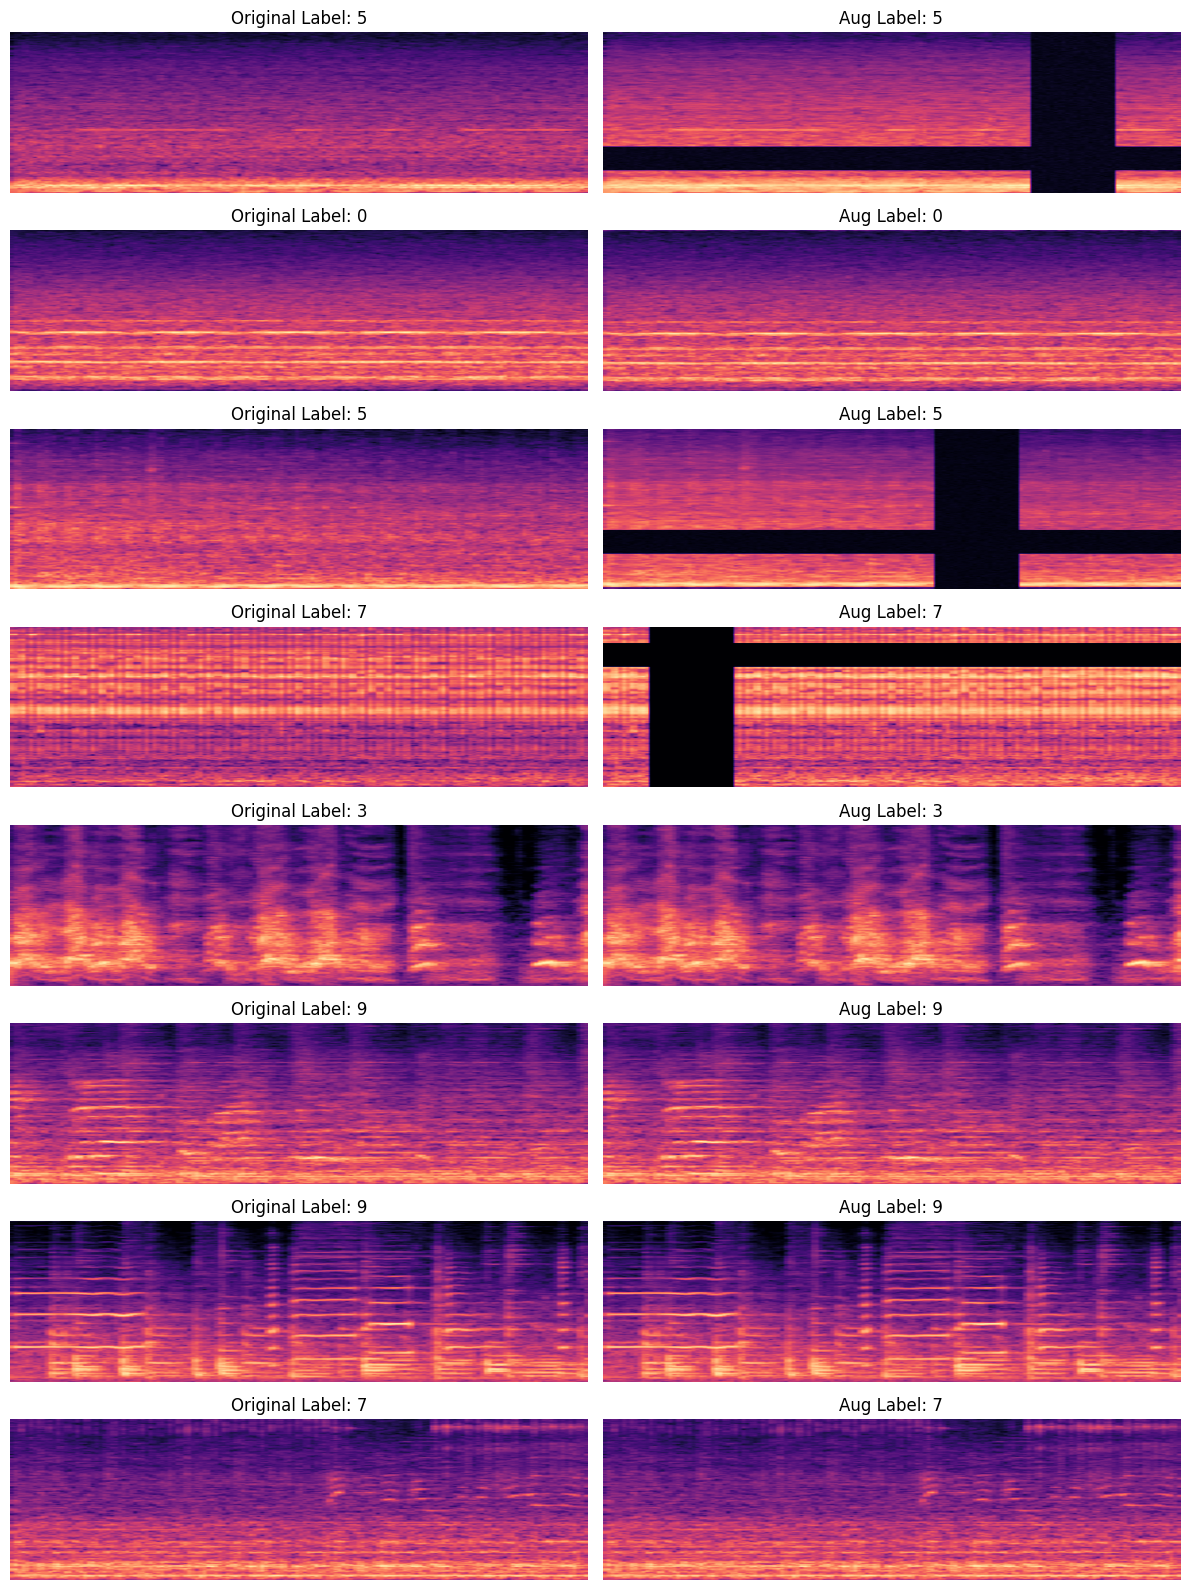

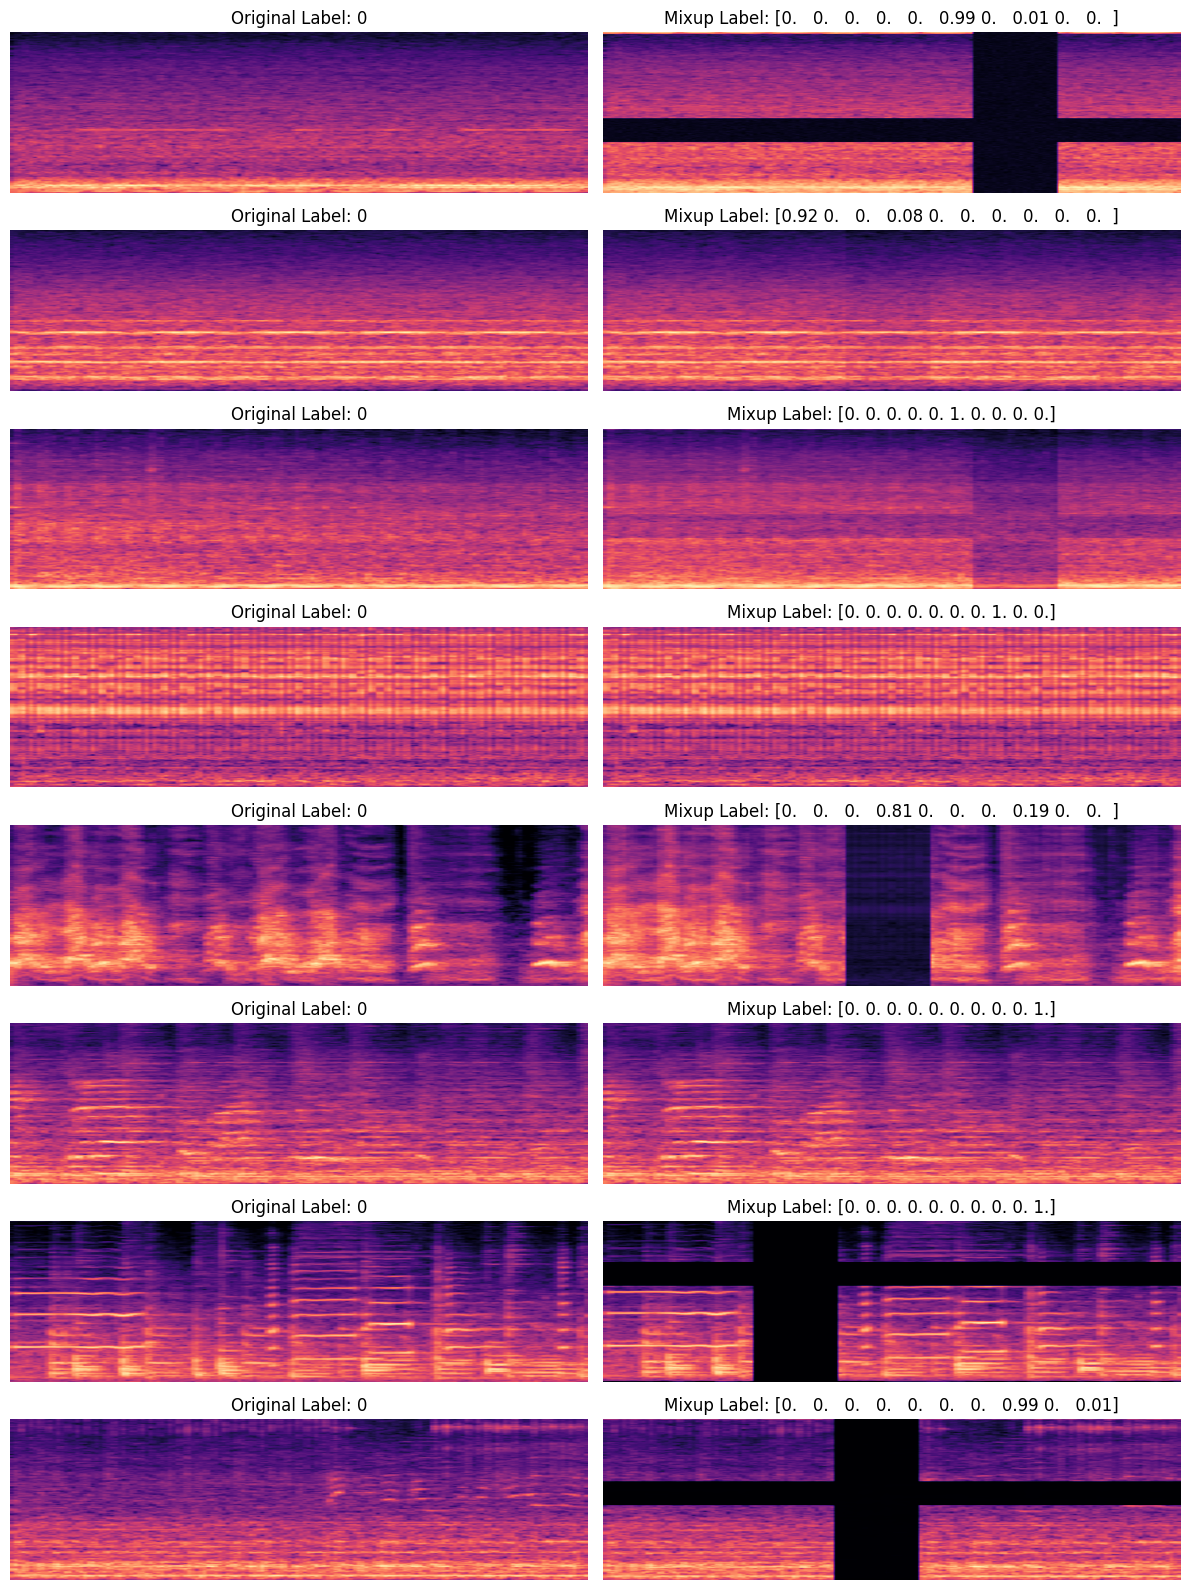

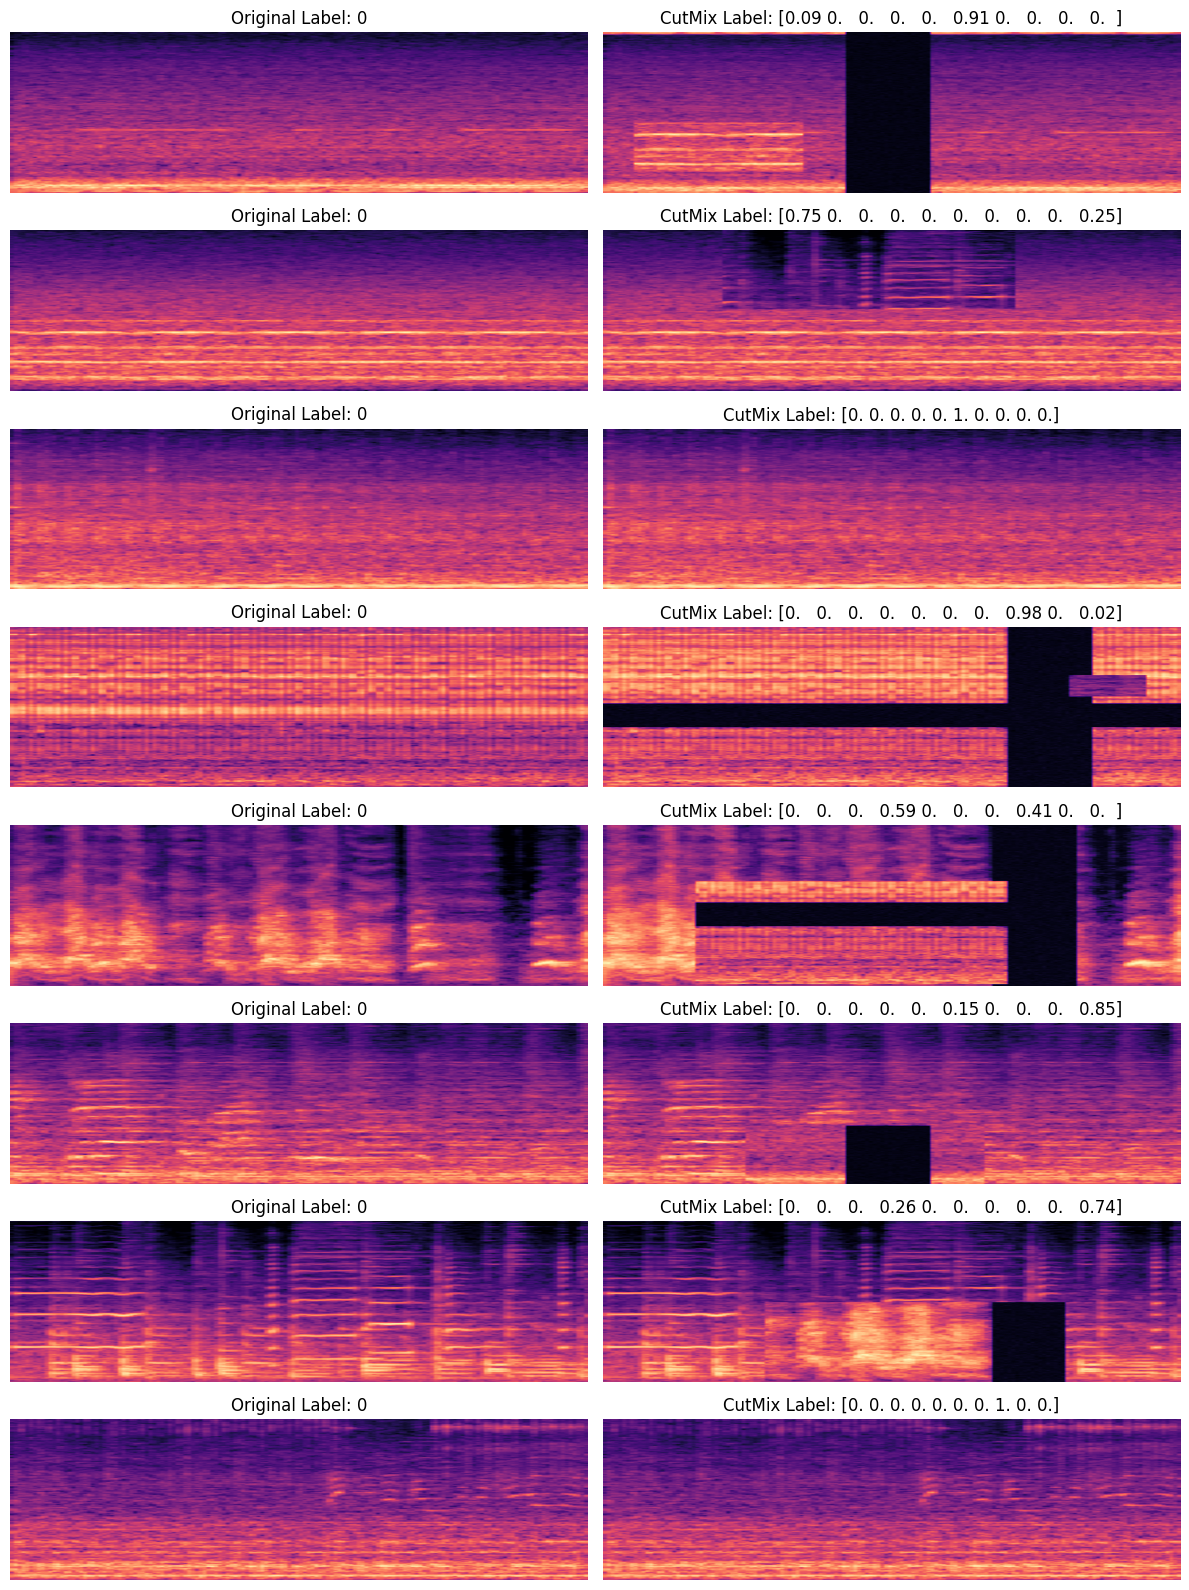

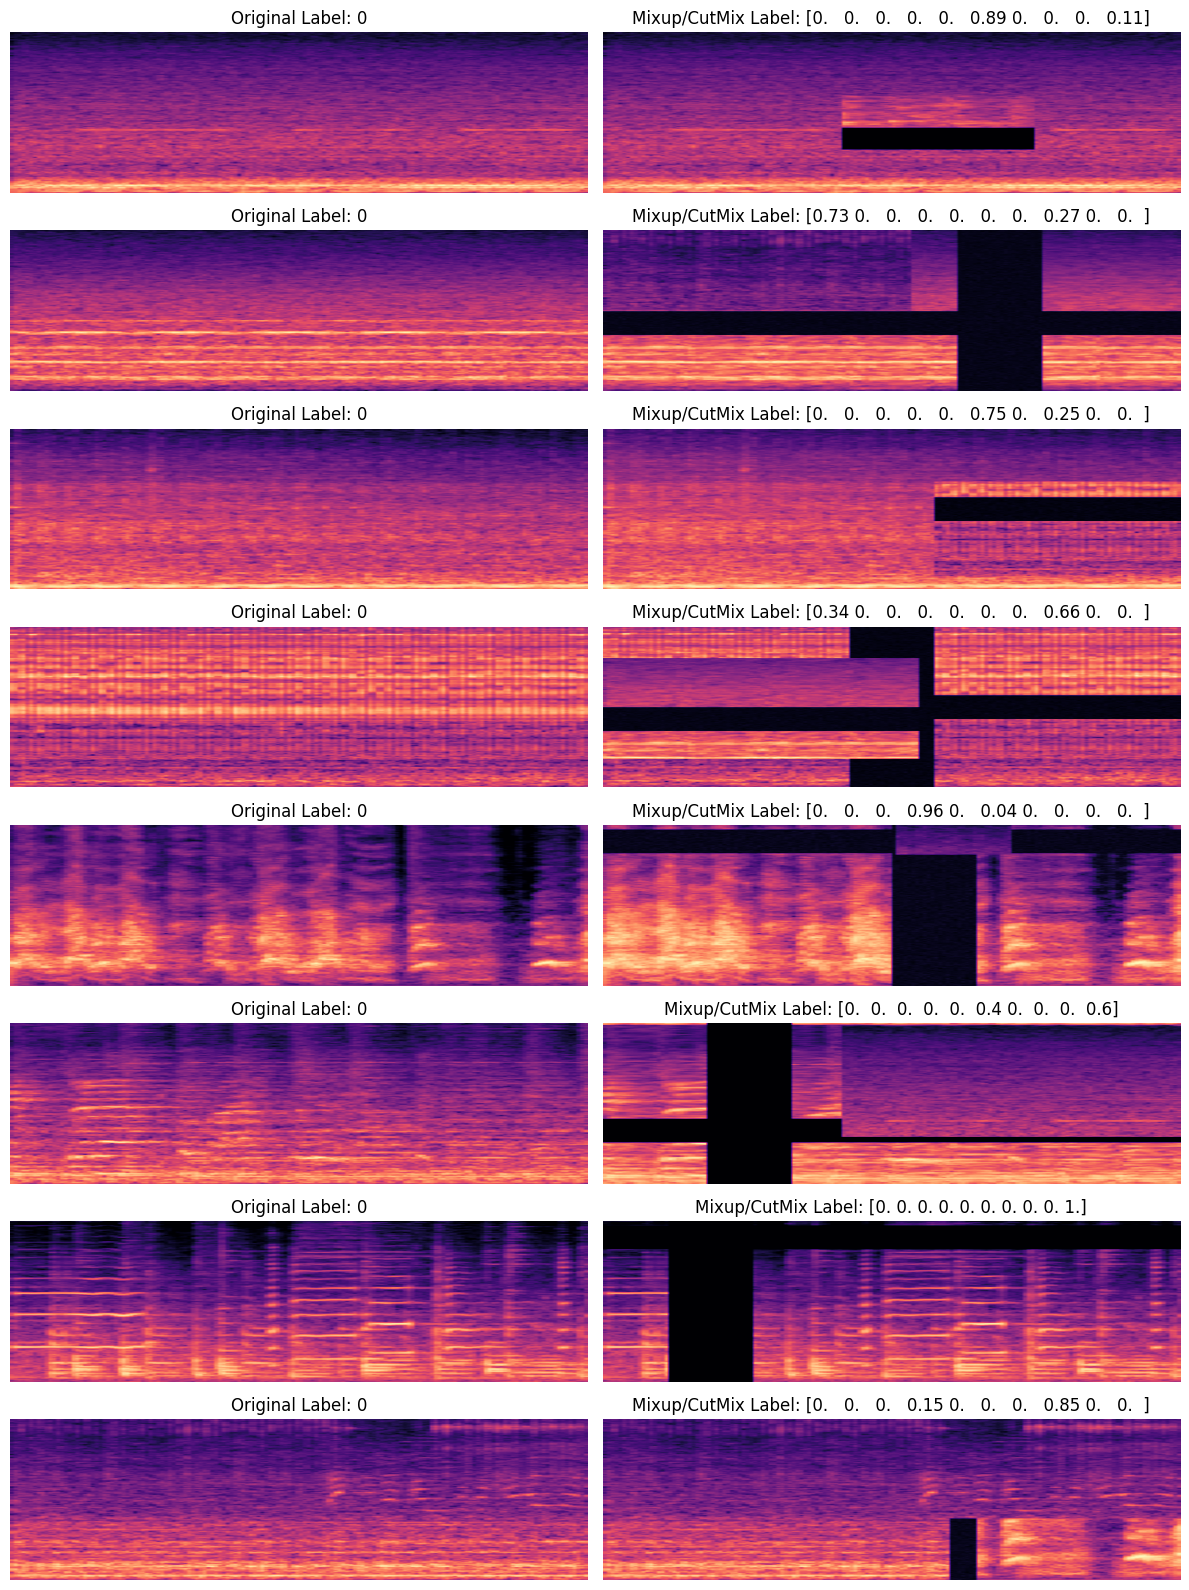

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


# === Sample real data from df ===
sample_df = df.sample(8, random_state=np.random.randint(99999))
sample_paths = sample_df["mel_path"].values
sample_labels = sample_df["classID"].values

# === Create datasets ===
ds_plain = create_mel_dataset(sample_paths, sample_labels, batch_size=8, augment=False, mix_strategy="none", shuffle=False)
ds_aug   = create_mel_dataset(sample_paths, sample_labels, batch_size=8, augment=True,  mix_strategy="none",   shuffle=False)
ds_mix   = create_mel_dataset(sample_paths, sample_labels, batch_size=8, augment=True,  mix_strategy="mixup",  shuffle=False)
ds_cut   = create_mel_dataset(sample_paths, sample_labels, batch_size=8, augment=True,  mix_strategy="cutmix", shuffle=False)
ds_both  = create_mel_dataset(sample_paths, sample_labels, batch_size=8, augment=True,  mix_strategy="both",   shuffle=False)

# === Visualization function ===
def visualize_pairwise(original_ds, aug_ds, is_soft=False, title_prefix="Aug"):
    mels_orig, labels_orig = next(iter(original_ds))
    mels_aug,  labels_aug  = next(iter(aug_ds))

    plt.figure(figsize=(12, 16))
    for i in range(len(mels_orig)):
        # Original
        plt.subplot(len(mels_orig), 2, 2*i + 1)
        plt.imshow(tf.squeeze(mels_orig[i]), aspect="auto", origin="lower", cmap="magma")
        label_display = f"{np.argmax(labels_orig[i])}" if is_soft else f"{int(labels_orig[i])}"
        plt.title(f"Original Label: {label_display}")
        plt.axis("off")

        # Augmented / Mixup / CutMix
        plt.subplot(len(mels_orig), 2, 2*i + 2)
        plt.imshow(tf.squeeze(mels_aug[i]), aspect="auto", origin="lower", cmap="magma")
        label_display = f"{np.round(labels_aug[i].numpy(), 2)}" if is_soft else f"{int(labels_aug[i])}"
        plt.title(f"{title_prefix} Label: {label_display}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# === Show all variants ===
try:
    visualize_pairwise(ds_plain, ds_aug, is_soft=False, title_prefix="Aug")
except Exception as e:
    print(f"[Error] Aug visualization failed: {e}")

try:
    visualize_pairwise(ds_plain, ds_mix, is_soft=True, title_prefix="Mixup")
except Exception as e:
    print(f"[Error] Mixup visualization failed: {e}")

try:
    visualize_pairwise(ds_plain, ds_cut, is_soft=True, title_prefix="CutMix")
except Exception as e:
    print(f"[Error] CutMix visualization failed: {e}")

try:
    visualize_pairwise(ds_plain, ds_both, is_soft=True, title_prefix="Mixup/CutMix")
except Exception as e:
    print(f"[Error] Mixup/CutMix visualization failed: {e}")


# Model Architecture
---
### TODO:

-  ~Do not forget to activate adamw in next training -- Right now its adam because we already started tuning~
- ~Consider usig gelu activation instead of tuning it. We already now its performing well in our model.~
- ~Consider using resudial_block as default isntead of tuning it.~
- ~Consider using regular as concolution type instead of tuning it.~

---

In [6]:
import tensorflow as tf

# === Attention block skipped per design ===

def residual_block(x, filters, l2_val, activation="relu"):
    """Residual block with always-on SE attention and fixed batch norm."""
    shortcut = x
    norm = tf.keras.layers.BatchNormalization

    x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same",
                               kernel_regularizer=tf.keras.regularizers.l2(l2_val))(x)
    x = norm()(x)
    x = tf.keras.layers.Activation(activation)(x)

    x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same",
                               kernel_regularizer=tf.keras.regularizers.l2(l2_val))(x)
    x = norm()(x)

    # SE block always enabled with residuals
    se = tf.keras.layers.GlobalAveragePooling2D()(x)
    se = tf.keras.layers.Dense(filters // 8, activation='relu')(se)
    se = tf.keras.layers.Dense(filters, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape((1, 1, filters))(se)
    x = tf.keras.layers.Multiply()([x, se])

    if x.shape[-1] != shortcut.shape[-1]:
        shortcut = tf.keras.layers.Conv2D(filters, (1, 1), padding="same",
                                          kernel_regularizer=tf.keras.regularizers.l2(l2_val))(shortcut)
        shortcut = norm()(shortcut)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation(activation)(x)
    return x


def conv_layer(filters, kernel_size, padding, l2_val, conv_type):
    """Returns a convolutional layer (regular or separable) with L2 regularization."""
    if conv_type == "regular":
        return tf.keras.layers.Conv2D(filters, kernel_size, padding=padding,
                                      kernel_regularizer=tf.keras.regularizers.l2(l2_val))
    else:
        return tf.keras.layers.SeparableConv2D(filters, kernel_size, padding=padding,
                                               depthwise_regularizer=tf.keras.regularizers.l2(l2_val),
                                               pointwise_regularizer=tf.keras.regularizers.l2(l2_val))


def build_model(hp, mix=False):
    """
    Builds a CNN model for mel-spectrogram classification.
    Simplified for faster tuning: fewer HPs, uses ReduceLROnPlateau externally.
    """
    # === Tunable Hyperparameters ===
    dropout_rate = hp.Float("dropout", 0.3, 0.6, step=0.1)
    l2_val = hp.Float("l2", 1e-5, 1e-3, sampling="log")
    filters_start = hp.Choice("filters_start", [32, 48, 64])
    #depth = hp.Int("depth", 2, 4)
    dense_units = hp.Choice("dense_units", [64, 128, 256])
    #use_residual = hp.Boolean("use_residual")
    #conv_type = hp.Choice("conv_type", ["regular", "separable"])
    activation = hp.Choice("activation", ["swish", "gelu"])      #Eleminated relu
    lr_val = hp.Float("learning_rate", 1e-4, 1e-3, sampling="log")

    # === Fixed Configuration ===
    num_dense = 1               # fixed
    pool_type = "max"           # fixed
    norm_type = "batch"         # fixed
    use_attention = False       # removed
    # Learning rate scheduler removed in favor of ReduceLROnPlateau
    depth = 4 
    conv_type = "regular"
    use_residual = True

    NormLayer = tf.keras.layers.BatchNormalization

    inputs = tf.keras.Input(shape=(256, 150, 1))
    x = inputs
    filters = filters_start

    for _ in range(depth):
        if use_residual:
            x = residual_block(x, filters, l2_val, activation=activation)
        else:
            x = conv_layer(filters, (3, 3), "same", l2_val, conv_type)(x)
            x = NormLayer()(x)
            x = tf.keras.layers.Activation(activation)(x)

            x = conv_layer(filters, (3, 3), "same", l2_val, conv_type)(x)
            x = NormLayer()(x)
            x = tf.keras.layers.Activation(activation)(x)

        x = tf.keras.layers.MaxPooling2D((2, 2))(x)
        filters *= 2

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    for _ in range(num_dense):
        x = tf.keras.layers.Dense(dense_units, activation=activation,
                                  kernel_regularizer=tf.keras.regularizers.l2(l2_val))(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x)

    outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

    # Use fixed learning rate — scheduler logic moved to training callbacks
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        #optimizer=tf.keras.optimizers.Adam(learning_rate=lr_val),
        optimizer=tf.keras.optimizers.AdamW(weight_decay=l2_val, learning_rate=lr_val),   # Better with weight decay  ##################################
        loss='categorical_crossentropy' if mix else 'sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Model Summary and Graph

In [14]:
import tensorflow as tf
from keras_tuner import HyperParameters
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display, SVG

# === Manual HyperParameter Setup (must match latest build_model) ===
summary_hp = HyperParameters()

# Tunable parameters (based on current model definition)
summary_hp.Fixed("dropout", 0.5)                 # [0.3, 0.4, 0.5, 0.6]
summary_hp.Fixed("l2", 1e-4)                     # log-scale: 1e-5 to 1e-3
summary_hp.Fixed("filters_start", 48)           # [32, 48, 64]
summary_hp.Fixed("depth", 4)                    # [2, 3, 4]
summary_hp.Fixed("dense_units", 256)            # [64, 128, 256]
summary_hp.Fixed("use_residual", True)          # True / False
summary_hp.Fixed("conv_type", "regular")        # "regular" / "separable"
summary_hp.Fixed("activation", "gelu")         # "relu" / "swish" / "gelu"
summary_hp.Fixed("learning_rate", 1e-3)         # log-scale: 1e-4 to 1e-3

# === Build Model ===
model = build_model(summary_hp, mix=True)  # mix=True → categorical output

# === Show Summary ===
model.summary()

# === Plot and Display Architecture === Crashes in dept 4
#plot_model(model, to_file="model_architecture.svg", show_shapes=True, show_layer_names=True)
#display(SVG("model_architecture.svg"))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 150, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 256, 150, 48)   │            480 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 256, 150, 48)   │            192 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 256, 150, 48)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 256, 150, 48)   │         20,784 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 256, 150, 48)   │            192 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 48)             │              0 │ batch_normalization_1… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 6)              │            294 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 48)             │            336 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1, 1, 48)       │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 256, 150, 48)   │             96 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 256, 150, 48)   │              0 │ batch_normalization_1… │
│                           │                        │                │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 256, 150, 48)   │            192 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 256, 150, 48)   │              0 │ multiply[0][0],        │
│                           │                        │                │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 256, 150, 48)   │              0 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 128, 75, 48)    │              0 │ activation_1[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├──────────────────────

 Total params: 2,892,420 (11.03 MB)

 Trainable params: 2,888,100 (11.02 MB)

 Non-trainable params: 4,320 (16.88 KB)

# WarmupScheduler for learning rate 
---
#### TODO:
    - Each trial has its own target_lr, so the warmup starting LR differs slightly; this is normal and expected.
    - Optionally, add an on_train_begin print inside WarmupScheduler to clearly log start_lr, target_lr, and
---

In [7]:
import tensorflow as tf

class WarmupScheduler(tf.keras.callbacks.Callback):
    def __init__(self, max_epochs, target_lr, warmup_ratio=0.1, start_lr=1e-6, verbose=1):
        """
        Warmup scheduler that linearly increases the LR from start_lr to target_lr.

        Args:
            max_epochs: int, total number of epochs (used to auto-calculate warmup_epochs)
            target_lr: float, final learning rate after warmup
            warmup_ratio: float, portion of max_epochs for warmup (default 10%)
            start_lr: float, starting learning rate (default 1e-6)
            verbose: int, 0=silent, 1=print warmup events
        """
        super().__init__()
        self.max_epochs = max_epochs
        self.target_lr = target_lr
        self.start_lr = start_lr
        self.warmup_ratio = warmup_ratio
        self.verbose = verbose

        # How many epochs to warmup
        self.warmup_epochs = max(1, int(self.max_epochs * self.warmup_ratio))

    def _safe_set_lr(self, new_lr):
        """Safely assign learning rate if possible."""
        if not hasattr(self.model.optimizer, "learning_rate"):
            if self.verbose:
                print("[WarmupScheduler] Optimizer has no learning_rate attribute — skipping LR adjustment.")
            return

        lr_attr = self.model.optimizer.learning_rate

        # Check if it is assignable
        if hasattr(lr_attr, "assign"):
            lr_attr.assign(new_lr)
        else:
            if self.verbose:
                print(f"[WarmupScheduler] learning_rate is not assignable ({type(lr_attr)}), skipping.")

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            progress = (epoch + 1) / self.warmup_epochs
            new_lr = self.start_lr + (self.target_lr - self.start_lr) * progress
            self._safe_set_lr(new_lr)
            if self.verbose:
                print(f"[Warmup] Epoch {epoch+1}: Setting LR to {new_lr:.6f}")
        elif epoch == self.warmup_epochs:
            self._safe_set_lr(self.target_lr)
            if self.verbose:
                print(f"[Warmup] Epoch {epoch+1}: Warmup complete. LR={self.target_lr:.6f}")


# Hyperparameter Tuner - hyperband
---
### TODO:
- Migth try to develop a custom objective tha ttakes loss into account
---

In [8]:
import keras_tuner as kt
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import set_random_seed

def run_hyperparameter_tuning(file_paths, labels,
                               max_epochs=20,
                               factor=3,
                               hyperband_iterations=3,
                               project_name="mel_tuning",
                               batch_size=32,
                               mix_strategy="both",
                               mix_prob=0.3):
    """
    Runs Keras Tuner Hyperband for simplified model with WarmupScheduler.
    """

    # === Safety Checks ===
    if len(file_paths) == 0 or len(labels) == 0:
        raise ValueError("Input file_paths or labels are empty.")
    if not (0.0 <= mix_prob <= 1.0):
        raise ValueError("mix_prob must be between 0.0 and 1.0")
    if len(np.unique(labels)) < 2:
        raise ValueError("Need at least 2 classes for tuning.")
    if not tf.config.list_physical_devices('GPU'):
        print(" Warning: No GPU detected. Tuning will be slow.")

    # === Stratified Split ===
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, val_idx = next(sss.split(file_paths, labels))
    x_train, y_train = file_paths[train_idx], labels[train_idx]
    x_val, y_val = file_paths[val_idx], labels[val_idx]

    # === Class Weights ===
    class_weights = compute_class_weight(class_weight='balanced',
                                         classes=np.unique(y_train),
                                         y=y_train)
    class_weight_dict = {i: w for i, w in enumerate(class_weights)}
    print(f"Class Weights: {class_weight_dict}")

    # === Label format ===
    use_mix = mix_strategy != "none"

    # === Datasets ===
    train_ds = create_mel_dataset(x_train, y_train, batch_size=batch_size,
                                  augment=True, mix_strategy=mix_strategy,
                                  mix_prob=mix_prob, shuffle=True)
    val_ds = create_mel_dataset(x_val, y_val, batch_size=batch_size,
                                augment=False, mix_strategy="none",
                                return_onehot_labels=use_mix, shuffle=False)

    # === Sanity Check ===
    try:
        xb, yb = next(iter(train_ds))
        print(f"✅ Train batch: {xb.shape}, Labels: {yb.dtype}")
    except Exception as e:
        print(f"❌ DataLoader issue: {e}")
        return None

    # === Model Builder (wrapper to attach warmup) ===
    def model_builder(hp):
        model = build_model(hp, mix=use_mix)
        lr_val = hp.get("learning_rate")
        model.warmup_callback = WarmupScheduler(max_epochs=max_epochs,
                                                target_lr=lr_val,
                                                warmup_ratio=0.1,
                                                start_lr=1e-6,
                                                verbose=1)
        return model

    # === Custom Tuner that injects the warmup callback ===
    class WarmupTuner(kt.Hyperband):
        def run_trial(self, trial, *args, **kwargs):
            model = self.hypermodel.build(trial.hyperparameters)
            callbacks = kwargs.pop("callbacks", [])
            callbacks = callbacks + [model.warmup_callback]
            result = super().run_trial(trial, *args, callbacks=callbacks, **kwargs)
            return result


    tuner = WarmupTuner(
        model_builder,
        objective="val_accuracy",
        max_epochs=max_epochs,
        factor=factor,
        hyperband_iterations=hyperband_iterations,
        directory="tuner_results",
        project_name=project_name,
        overwrite=False,
        seed=SEED
    )

    # === Callbacks ===
    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),#make patience 15 ################################3
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, verbose=1)
    ]

    # === Run Tuning ===
    tuner.search(
        train_ds,
        validation_data=val_ds,
        epochs=max_epochs,
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )

    # === Get Best Trial ===
    best_hps = tuner.get_best_hyperparameters(1)
    if not best_hps:
        raise RuntimeError("No valid trials completed.")

    best_hp = best_hps[0]
    print("\n Best Hyperparameters:")
    for param in best_hp.values:
        print(f"  {param}: {best_hp.get(param)}")

    return best_hp


## Custom Model Checkpoint Callback
##### Considers both val acc and vall loss
##### It has higher val_accuracy than all previous epochs
##### OR if the val_accuracy is the same as previous best, then pick the one with lower val_loss

In [10]:
import tensorflow as tf
import os

class BestModelSaver(tf.keras.callbacks.Callback):
    def __init__(self, save_path):
        super(BestModelSaver, self).__init__()
        self.save_path = save_path
        self.best_val_acc = -1.0
        self.best_val_loss = float('inf')

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        val_loss = logs.get('val_loss')

        if val_acc is None or val_loss is None:
            print("[Warning] val_accuracy or val_loss not available at epoch end.")
            return

        # If better accuracy, or same accuracy but lower loss
        if (val_acc > self.best_val_acc) or (val_acc == self.best_val_acc and val_loss < self.best_val_loss):
            print(f"Saving new best model at epoch {epoch+1}: val_accuracy={val_acc:.4f}, val_loss={val_loss:.4f}")
            self.model.save(self.save_path)
            self.best_val_acc = val_acc
            self.best_val_loss = val_loss


## Custom Callbacks -- Adjusted to the Warmup
---
### TODO: 

  - MOve this up and replace callbacks in hyperparametertuning too.   !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
---

In [11]:
class CustomEarlyStopping(tf.keras.callbacks.EarlyStopping):
    def __init__(self, warmup_epochs, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.warmup_epochs = warmup_epochs

    def on_epoch_end(self, epoch, logs=None):
        if epoch >= self.warmup_epochs:
            super().on_epoch_end(epoch, logs)

class CustomReduceLROnPlateau(tf.keras.callbacks.ReduceLROnPlateau):
    def __init__(self, warmup_epochs, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.warmup_epochs = warmup_epochs

    def on_epoch_end(self, epoch, logs=None):
        if epoch >= self.warmup_epochs:
            super().on_epoch_end(epoch, logs)


# Training 
---
### TODO: 
  - ~Replace ModelCheckpoint with custom callback that saves model only if val_accuracy improves, or if equal accuracy, lower val_loss.~
  - ~Add WarmupScheduler for learning rate (warm start learning rate slowly for first few epochs).  -%10 percent of to max epoch.~ 
  - NOTE: Dont forget to update the configuration of hyperarameter tuning to align training.
---
##### Training Loop (per Fold)

1. Start fold
2. Build and compile model
3. Define `WARMUP_RATIO` (e.g., 0.1)
4. Calculate `warmup_epochs = int(epochs * WARMUP_RATIO)`

##### Callbacks Attached:
- BestModelSaver → always active
- WarmupScheduler → adjusts LR linearly during warmup
- CustomEarlyStopping → ONLY active after warmup
- CustomReduceLROnPlateau → ONLY active after warmup
- CSVLogger → always active

##### During Training:
```
For each epoch:
    ├── WarmupScheduler:
    │     ├── If epoch <= warmup_epochs:
    │     │     └── Gradually increase learning rate
    │     └── Else:
    │           └── Keep learning rate constant
    │
    ├── CustomEarlyStopping:
    │     ├── If epoch <= warmup_epochs:
    │     │     └── Ignore val_accuracy
    │     └── Else:
    │           └── Monitor val_accuracy and stop if patience exceeded
    │
    └── CustomReduceLROnPlateau:
          ├── If epoch <= warmup_epochs:
          │     └── Ignore val_accuracy
          └── Else:
                └── Reduce LR if val_accuracy plateaus for patience epochs
```
##### After Training:
- Best model saved automatically
- Training logs saved
- Training history saved

---

In [12]:
import os
import json
from datetime import datetime
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, ReduceLROnPlateau
from tensorflow.keras.utils import set_random_seed


def train_kfold(file_paths, labels, best_hp,
                n_splits=5,
                epochs=50,
                batch_size=32,
                mix_strategy="both",
                mix_prob=0.6,
                model_dir="models"):
    """
    Trains model using Stratified K-Fold CV. Supports:
    - WarmupScheduler (dynamic)
    - Custom EarlyStopping after warmup
    - Custom ReduceLROnPlateau after warmup
    - Mixup/CutMix
    - Logging (CSV and JSON)
    """
    use_mix = mix_strategy != "none"
    WARMUP_RATIO = 0.1   # Easy global warmup control

    if best_hp is None:
        raise ValueError("No hyperparameters provided. Pass best_hp from tuner.")
    
    if not tf.config.list_physical_devices('GPU'):
        print("WARNING: No GPU detected. Training will be slow.")

    set_random_seed(SEED)
    os.makedirs(model_dir, exist_ok=True)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(file_paths, labels)):
        fold_name = f"fold_{fold + 1}"
        model_path = os.path.join(model_dir, f"{fold_name}_best_model.keras")
        csv_log_path = os.path.join(model_dir, f"{fold_name}_log.csv")
        history_path = os.path.join(model_dir, f"{fold_name}_history.json")

        print(f"\nStarting {fold_name}...")

        if os.path.exists(model_path):
            print(f"Model already exists at {model_path}. Skipping.")
            fold_metrics.append({
                "fold": fold + 1,
                "val_accuracy": None,
                "val_loss": None,
                "model_path": model_path,
                "csv_log": csv_log_path,
                "history": None
            })
            continue

        x_train, y_train = file_paths[train_idx], labels[train_idx]
        x_val, y_val = file_paths[val_idx], labels[val_idx]

        class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
        class_weight_dict = {i: w for i, w in enumerate(class_weights)}
        print(f"Class Weights: {class_weight_dict}")

        # === Datasets ===
        train_ds = create_mel_dataset(x_train, y_train, batch_size=batch_size,
                                      augment=True, mix_strategy=mix_strategy,
                                      mix_prob=mix_prob, shuffle=True)

        val_ds = create_mel_dataset(x_val, y_val, batch_size=batch_size,
                                    augment=False, mix_strategy="none",
                                    return_onehot_labels=use_mix, shuffle=False)

        # Sanity Check
        try:
            xb, yb = next(iter(train_ds))
            print(f"✅ Train batch: x={xb.shape}, y={yb.shape}")
            xb, yb = next(iter(val_ds))
            print(f"✅ Val batch: x={xb.shape}, y={yb.shape}")
        except Exception as e:
            print(f"❌ Data loading error (fold {fold + 1}): {e}")
            continue

        # === Build & Compile Model ===
        model = build_model(best_hp, mix=use_mix)

        # === WarmupScheduler: get learning rate from best_hp
        lr_val = best_hp.get("learning_rate")
        warmup_callback = WarmupScheduler(
            max_epochs=epochs,
            target_lr=lr_val,
            warmup_ratio=WARMUP_RATIO,
            start_lr=1e-6,
            verbose=1
        )

        warmup_epochs = int(epochs * WARMUP_RATIO)

        callbacks = [
            BestModelSaver(model_path),
            CustomEarlyStopping(warmup_epochs=warmup_epochs, monitor="val_accuracy", patience=20, restore_best_weights=True),
            CustomReduceLROnPlateau(warmup_epochs=warmup_epochs, monitor="val_accuracy", factor=0.5, patience=5, verbose=1),
            CSVLogger(csv_log_path),
            warmup_callback
        ]

        # === Training ===
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs,
            callbacks=callbacks,
            class_weight=class_weight_dict,
            verbose=1
        )

        best_acc = max(history.history['val_accuracy'])
        best_loss = min(history.history['val_loss'])

        print(f"{fold_name} done. Best acc: {best_acc:.4f}")

        # Save training history
        with open(history_path, "w") as f:
            json.dump(history.history, f)

        fold_metrics.append({
            "fold": fold + 1,
            "val_accuracy": best_acc,
            "val_loss": best_loss,
            "model_path": model_path,
            "csv_log": csv_log_path,
            "history": history.history
        })

    # === Final Summary ===
    print("\nFinal Fold Summary:")
    for m in fold_metrics:
        print(f"  Fold {m['fold']}: acc={m['val_accuracy']}, loss={m['val_loss']} → {m['model_path']}")

    return fold_metrics


# Get Mel Paths

In [13]:
def get_mel_paths_and_labels(df, cache_dir):
    """
    Matches cached .npy files with their original labels.
    Returns: (file_paths, labels) as np arrays
    """
    mel_paths = []
    mel_labels = []

    for _, row in df.iterrows():
        mel_path = os.path.join(
            cache_dir,
            os.path.basename(row["file_name"]).replace(".wav", "_mel.npy")
        )
        if os.path.exists(mel_path):
            mel_paths.append(mel_path)
            mel_labels.append(row["classID"])

    return np.array(mel_paths), np.array(mel_labels)

In [ ]:
# Extract zip
zip_path="/kaggle/input/tuner_results_archive.zip"
extract_to="/kaggle/working/tuner_results"
                        
if os.path.exists(zip_path):
    print(" Unpacking tuner archive...")
    shutil.unpack_archive(zip_path, extract_to)
    print(" Archive extracted.")

 # Starting Hyperparameter Tuning

In [16]:
mel_paths, mel_labels = get_mel_paths_and_labels(df, CACHE_DIR)

best_hp = run_hyperparameter_tuning(
    file_paths=mel_paths,
    labels=mel_labels,
    max_epochs=50,            # Migth need tuning
    factor=3,
    hyperband_iterations=3,
    project_name="mel_tuning",
    batch_size=32,             #
    mix_strategy="both",       #
    mix_prob=0.6               # may requate tuning
)

Trial 270 Complete [00h 29m 04s]
val_accuracy: 0.9780453443527222

Best val_accuracy So Far: 0.9787535667419434
Total elapsed time: 2d 01h 24m 27s

 Best Hyperparameters:
  dropout: 0.4
  l2: 1.9916530306246385e-05
  filters_start: 64
  dense_units: 128
  activation: gelu
  learning_rate: 0.0005066993444292604
  tuner/epochs: 50
  tuner/initial_epoch: 17
  tuner/bracket: 3
  tuner/round: 3
  tuner/trial_id: 0136


In [27]:
#Turn tuner file to zip
import shutil

# Path to the folder you want to zip
input_dir = '/kaggle/working/models'

# Path (without extension) where the .zip will be saved
output_zip = '/kaggle/working/models'

# Create a ZIP file
shutil.make_archive(output_zip, 'zip', input_dir)

print(f"Created archive at: {output_zip}.zip")


Created archive at: /kaggle/working/models.zip


In [28]:
# Download Link
from IPython.display import FileLink
FileLink(r'models.zip')


/kaggle/working/models.zip

In [15]:
import zipfile
import os
import shutil

# Define paths
source_path = '/kaggle/input/tuner-results-28-04-25'
destination_dir = '/kaggle/working'
tuner_results_path = os.path.join(destination_dir, 'tuner_results')

# Ensure clean destination
if os.path.exists(tuner_results_path):
    shutil.rmtree(tuner_results_path)
os.makedirs(tuner_results_path, exist_ok=True)

# Check if source is a zip file
if zipfile.is_zipfile(source_path):
    with zipfile.ZipFile(source_path, 'r') as zip_ref:
        zip_ref.extractall(tuner_results_path)
    print("Zip archive successfully extracted to:", tuner_results_path)
elif os.path.isdir(source_path):
    shutil.copytree(source_path, tuner_results_path, dirs_exist_ok=True)
    print("Folder copied to:", tuner_results_path)
else:
    # Single file, rename it to "tuner_results" with original extension
    ext = os.path.splitext(source_path)[1]
    destination_file = os.path.join(tuner_results_path, f"tuner_results{ext}")
    shutil.copy2(source_path, destination_file)
    print("Single file copied and renamed to:", destination_file)


Folder copied to: /kaggle/working/tuner_results


In [29]:
# File Delete 
import os

file_path = '/kaggle/working/models.zip'

if os.path.isfile(file_path):
    os.remove(file_path)
    print(f"Deleted: {file_path}")
else:
    print(f"No such file: {file_path}")


Deleted: /kaggle/working/models.zip


In [34]:
# Directory Delete
import shutil
import os

path = "/kaggle/working/tuner_results--"

# Check if the directory exists before trying to delete
if os.path.exists(path):
    shutil.rmtree(path)
    print(f"Deleted: {path}")
else:
    print(f"Directory does not exist: {path}")


Deleted: /kaggle/working/tuner_results


# Helper funcs for train 

In [14]:
import os
import shutil
import keras_tuner as kt

# === Load From Local Tuner Directory ===
def get_best_hp_if_exists(tuner_dir="tuner_results", project_name="mel_tuning"):
    tuner_path = os.path.join(tuner_dir, project_name)
    if os.path.exists(tuner_path):
        print("Found local tuner results.")
        tuner = kt.Hyperband(
            lambda hp: build_model(hp, mix=True),
            objective="val_accuracy",
            max_epochs=50,
            factor=3,
            hyperband_iterations=3,
            directory=tuner_dir,
            project_name=project_name,
            seed=SEED
        )
        best_hp = tuner.get_best_hyperparameters(1)
        if best_hp:
            print("\nBest Hyperparameters:")
            for param in best_hp[0].values:
                print(f"  {param}: {best_hp[0].get(param)}")
            return best_hp[0]
    print("No local tuner results found.")
    return None


# === Load From Uploaded Directory (Kaggle-style) ===
def get_best_hp_from_upload(tuner_dir="/kaggle/input/tuner-results", project_name="mel_tuning"):
    tuner_path = os.path.join(tuner_dir, project_name)
    if os.path.exists(tuner_path):
        print("Found tuner results in uploaded directory.")
        tuner = kt.Hyperband(
            lambda hp: build_model(hp, mix=True),
            objective="val_accuracy",
            max_epochs=50,
            factor=3,
            hyperband_iterations=3,
            directory=tuner_dir,
            project_name=project_name,
            seed=SEED
        )
        best_hp = tuner.get_best_hyperparameters(1)
        if best_hp:
            print("\n Best Hyperparameters:")
            for param in best_hp[0].values:
                print(f"  {param}: {best_hp[0].get(param)}")
            return best_hp[0]
    print("No uploaded tuner directory found.")
    return None


# === Load From ZIP Archive ===
def get_best_hp_from_zip(zip_path="/kaggle/input/tuner-results.zip",
                         extract_to="/kaggle/working/tuner_results",
                         project_name="mel_tuning"):
    if os.path.exists(zip_path):
        print("Extracting tuner ZIP archive...")
        shutil.unpack_archive(zip_path, extract_to)
        print("Archive extracted.")
        tuner = kt.Hyperband(
            lambda hp: build_model(hp, mix=True),
            objective="val_accuracy",
            max_epochs=50,
            factor=3,
            hyperband_iterations=3,
            directory=extract_to,
            project_name=project_name,
            overwrite=False,
            seed=SEED
        )
        best_hp = tuner.get_best_hyperparameters(1)
        if best_hp:
            print("\n Best Hyperparameters:")
            for param in best_hp[0].values:
                print(f"  {param}: {best_hp[0].get(param)}")
            return best_hp[0]
    print("No tuner ZIP archive found.")
    return None


# === Unified Launcher ===
def try_train_if_hp_available(
    mel_paths,
    mel_labels,
    n_splits=5,
    epochs=100,
    batch_size=32,
    mix_strategy="both",
    mix_prob=0.6,
    project_name="mel_tuning",
    model_save_dir="/kaggle/working/models"
):
    """
    Attempts to load best hyperparameters and launch k-fold training.
    Tries local dir → Kaggle dir → ZIP archive.
    """

    best_hp_local = None

    # Check if already exists in global scope
    if "best_hp" in globals() and best_hp is not None:
        best_hp_local = best_hp

    if best_hp_local is None:
        best_hp_local = get_best_hp_if_exists(project_name=project_name)

    if best_hp_local is None:
        best_hp_local = get_best_hp_from_upload(project_name=project_name)

    if best_hp_local is None:
        best_hp_local = get_best_hp_from_zip(project_name=project_name)

    if best_hp_local is not None:
        print("\nLaunching K-Fold training with best hyperparameters...")
        train_kfold(
            file_paths=mel_paths,
            labels=mel_labels,
            best_hp=best_hp_local,
            n_splits=n_splits,
            epochs=epochs,
            batch_size=batch_size,
            mix_strategy=mix_strategy,
            mix_prob=mix_prob,
            model_dir=model_save_dir
        )
    else:
        print("No valid hyperparameters found — training skipped.")


In [19]:
mel_paths, mel_labels = get_mel_paths_and_labels(df, CACHE_DIR)

fold_metrics = try_train_if_hp_available(
    mel_paths=mel_paths,
    mel_labels=mel_labels,

    n_splits=5,
    epochs=100,                              # Longer training for better convergence
    batch_size=32,

    project_name="mel_tuning",

    mix_strategy="both",                     # Enables both mixup and cutmix
    mix_prob=0.6,                            # Higher chance of mixup over cutmix

    model_save_dir="/kaggle/working/models"
)


Found local tuner results.
Reloading Tuner from tuner_results/mel_tuning/tuner0.json

Best Hyperparameters:
  dropout: 0.4
  l2: 1.9916530306246385e-05
  filters_start: 64
  dense_units: 128
  activation: gelu
  learning_rate: 0.0005066993444292604
  tuner/epochs: 50
  tuner/initial_epoch: 17
  tuner/bracket: 3
  tuner/round: 3
  tuner/trial_id: 0136

Launching K-Fold training with best hyperparameters...

Starting fold_1...
Model already exists at /kaggle/working/models/fold_1_best_model.keras. Skipping.

Starting fold_2...
Model already exists at /kaggle/working/models/fold_2_best_model.keras. Skipping.

Starting fold_3...
Model already exists at /kaggle/working/models/fold_3_best_model.keras. Skipping.

Starting fold_4...
Model already exists at /kaggle/working/models/fold_4_best_model.keras. Skipping.

Starting fold_5...
Model already exists at /kaggle/working/models/fold_5_best_model.keras. Skipping.

Final Fold Summary:
  Fold 1: acc=None, loss=None → /kaggle/working/models/fold_

# Train Process Examination

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import os
import json

def smooth_curve(values, weight=0.6):
    """Exponential Moving Average (EMA) smoother."""
    smoothed = []
    last = values[0]
    for val in values:
        smoothed_val = last * weight + (1 - weight) * val
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

def plot_kfold_training_histories(
    fold_metrics=None,
    model_dir="models",
    save_dir=None,
    smooth=False,
    show_best=True,
    show_stop=True,
    show_warmup=True,
    warmup_ratio=0.1
):
    """
    Plotting for training/validation accuracy and loss per fold + final summary.
    """
    if fold_metrics is None:
        print(f"Loading fold histories from: {model_dir}")
        fold_metrics = []
        for fname in sorted(os.listdir(model_dir)):
            if fname.endswith("_history.json"):
                try:
                    fold_num = int(fname.split("_")[1])
                except ValueError:
                    continue
                with open(os.path.join(model_dir, fname), "r") as f:
                    history = json.load(f)
                fold_metrics.append({
                    "fold": fold_num,
                    "val_accuracy": max(history.get("val_accuracy", [0])),
                    "val_loss": min(history.get("val_loss", [0])),
                    "model_path": os.path.join(model_dir, f"fold_{fold_num}_best_model.keras"),
                    "history": history
                })
        if not fold_metrics:
            print("No fold history files found.")
            return
    else:
        print("Using in-memory fold metrics.")

    final_summary = []

    # Plot each fold
    for metrics in sorted(fold_metrics, key=lambda m: m["fold"]):
        history = metrics.get("history")
        fold = metrics.get("fold")

        if not history:
            print(f"Skipping Fold {fold} — no training history.")
            continue

        epochs = list(range(1, len(history["accuracy"]) + 1))
        acc = history["accuracy"]
        val_acc = history["val_accuracy"]
        loss = history["loss"]
        val_loss = history["val_loss"]

        if smooth:
            acc = smooth_curve(acc)
            val_acc = smooth_curve(val_acc)
            loss = smooth_curve(loss)
            val_loss = smooth_curve(val_loss)

        best_epoch = int(np.argmax(history["val_accuracy"])) + 1
        best_val_acc = max(history["val_accuracy"])
        best_val_loss = min(history["val_loss"])
        warmup_end_epoch = int(len(epochs) * warmup_ratio)

        # Save final summary
        final_summary.append({
            "fold": fold,
            "best_val_accuracy": best_val_acc,
            "best_val_loss": best_val_loss
        })

        # Combined Accuracy + Loss figure 
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Accuracy
        axes[0].plot(epochs, acc, label="Train Accuracy", color="tab:blue")
        axes[0].plot(epochs, val_acc, label="Val Accuracy", color="tab:orange")
        if show_stop:
            axes[0].axvline(best_epoch, color="green", linestyle="--", label=f"Best Epoch: {best_epoch}")
        if show_warmup:
            axes[0].axvline(warmup_end_epoch, color="red", linestyle=":", label=f"Warmup End: {warmup_end_epoch}")

        acc_title = f"Fold {fold} Accuracy"
        if show_best:
            acc_title += f" (Best Val: {best_val_acc:.4f})"
        axes[0].set_title(acc_title)
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Accuracy")
        axes[0].legend()
        axes[0].grid(True)

        # Loss
        axes[1].plot(epochs, loss, label="Train Loss", color="tab:green")
        axes[1].plot(epochs, val_loss, label="Val Loss", color="tab:red")
        if show_stop:
            axes[1].axvline(best_epoch, color="green", linestyle="--", label=f"Best Epoch: {best_epoch}")
        if show_warmup:
            axes[1].axvline(warmup_end_epoch, color="red", linestyle=":", label=f"Warmup End: {warmup_end_epoch}")

        loss_title = f"Fold {fold} Loss"
        if show_best:
            loss_title += f" (Best Val Loss: {best_val_loss:.4f})"
        axes[1].set_title(loss_title)
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Loss")
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()

        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"fold_{fold}_combined.png")
            plt.savefig(save_path)
            print(f"Saved: {save_path}")

        plt.show()

    # Final Summary
    print("\nFinal Fold Results Summary:")
    print(f"{'Fold':<6} {'Best Val Acc':<18} {'Best Val Loss':<18}")
    print("-" * 45)
    for summary in final_summary:
        print(f"{summary['fold']:<6} {summary['best_val_accuracy']:<18.4f} {summary['best_val_loss']:<18.4f}")
    print("-" * 45)


Loading fold histories from: models


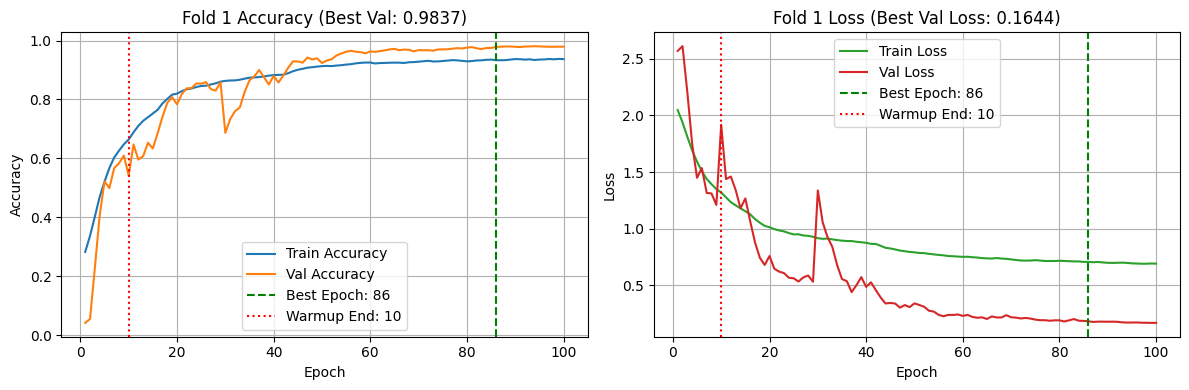

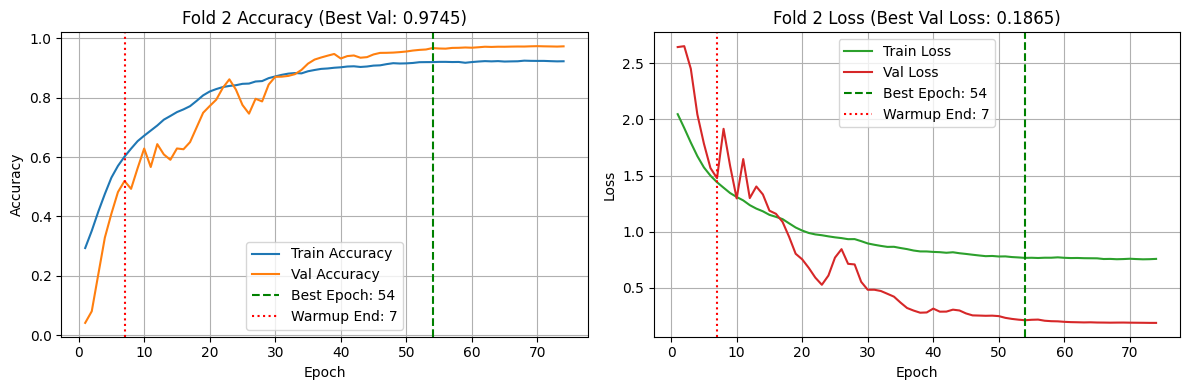

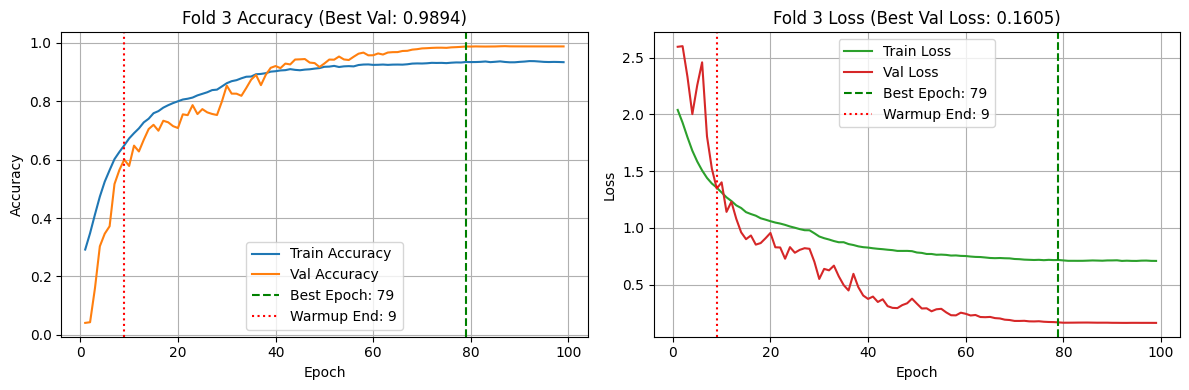

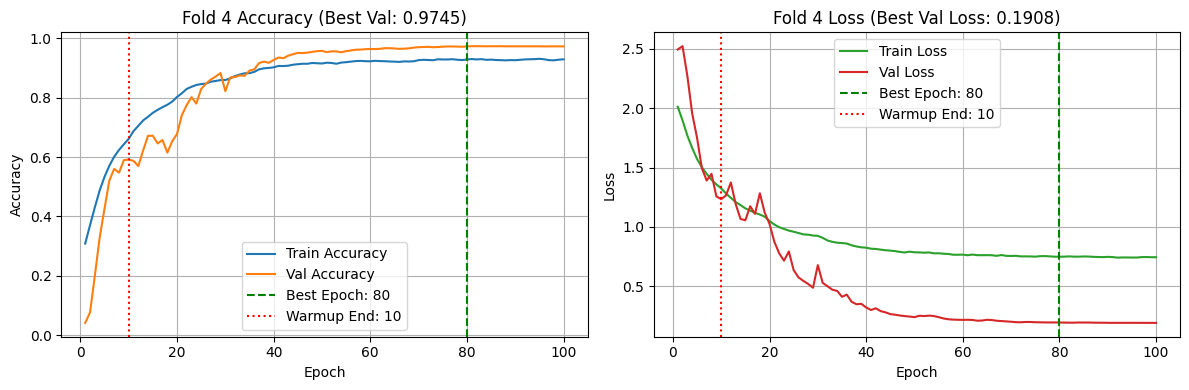

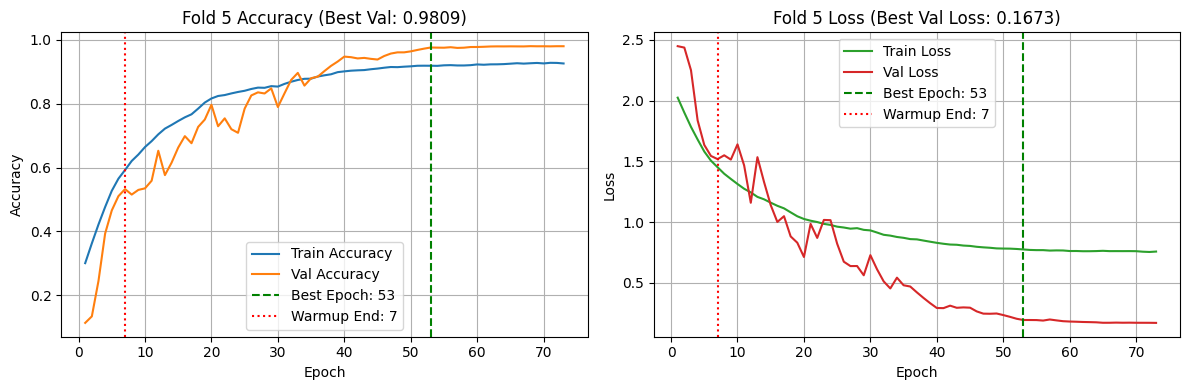


Final Fold Results Summary:
Fold   Best Val Acc       Best Val Loss     
---------------------------------------------
1      0.9837             0.1644            
2      0.9745             0.1865            
3      0.9894             0.1605            
4      0.9745             0.1908            
5      0.9809             0.1673            
---------------------------------------------


In [26]:
# Basic:
#plot_kfold_training_histories(fold_metrics=fold_metrics)

# With smoothing and early stopping markers:
plot_kfold_training_histories(fold_metrics=fold_metrics, smooth=True)

# With saving:
#plot_kfold_training_histories(fold_metrics=fold_metrics, save_dir="plots", smooth=True)


# Inference - Performance Test 
---
### TODO:
- Add test loss too.
---

In [22]:
import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import load_model
from tqdm import tqdm

# === Constants ===
SR = 22050
N_MELS = 256
FMAX = 8000
FIXED_TIME_STEPS = 150
TEST_AUDIO_DIR = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Test_Public"
TEST_CSV_PATH = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Test_Public.csv"
CACHE_DIR = "/kaggle/working/test_mel_cache"
MODEL_DIR = "/kaggle/working/models"

os.makedirs(CACHE_DIR, exist_ok=True)

# === Load test metadata ===
df_test = pd.read_csv(TEST_CSV_PATH)
df_test["filepath"] = df_test["file_name"].apply(lambda x: os.path.join(TEST_AUDIO_DIR, x))

# === Cache test mel spectrograms ===
def cache_test_mels(df, cache_dir):
    mel_paths = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=" Caching test mel spectrograms"):
        wav_path = row["filepath"]
        mel_path = os.path.join(cache_dir, os.path.basename(wav_path).replace(".wav", "_mel.npy"))
        mel_paths.append(mel_path)

        if os.path.exists(mel_path):
            continue

        try:
            y, sr = librosa.load(wav_path, sr=SR)
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
            mel_db = librosa.util.fix_length(mel_db, size=FIXED_TIME_STEPS, axis=1)
            mel_db = np.expand_dims(mel_db, axis=-1)
            np.save(mel_path, mel_db)
        except Exception as e:
            print(f"[ERROR] {wav_path}: {e}")
            mel_paths[-1] = None

    df["mel_path"] = mel_paths
    return df[df["mel_path"].notnull()]

df_test = cache_test_mels(df_test, CACHE_DIR)
print(f"\n Total test samples cached: {len(df_test)}")


 Caching test mel spectrograms: 100%|██████████| 82/82 [00:17<00:00,  4.67it/s]


 Total test samples cached: 82


In [24]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import load_model
import os

# Load mels and labels
X_test = np.array([np.load(path) for path in df_test["mel_path"]])
y_test = df_test["classID"].values

# Load Models
models = []
model_paths = [os.path.join(MODEL_DIR, f"fold_{i}_best_model.keras") for i in range(1, 6)]
fold_accuracies = []
fold_losses = []    # <<< THIS was missing
all_probs = []

print("\n--- Individual Fold Evaluations ---")

for i, path in enumerate(model_paths):
    if os.path.exists(path):
        model = load_model(path)
        models.append(model)

        probs = model.predict(X_test, batch_size=32, verbose=0)
        preds = np.argmax(probs, axis=1)

        # Evaluate (loss, acc)
        loss, acc = model.evaluate(X_test, tf.keras.utils.to_categorical(y_test, num_classes=10), verbose=0)
        
        fold_accuracies.append(acc)
        fold_losses.append(loss)

        print(f"Fold {i+1} — Accuracy: {acc:.4f} | Loss: {loss:.4f}")
        print(classification_report(y_test, preds, digits=3))

        all_probs.append(probs)
    else:
        print(f"\n   Missing model: fold_{i+1}")

# Ensemble Soft Voting
avg_probs = np.mean(all_probs, axis=0)
soft_preds = np.argmax(avg_probs, axis=1)
soft_acc = accuracy_score(y_test, soft_preds)

print("\n--- Ensemble: Soft Voting ---")
print(f"Accuracy: {soft_acc:.4f}")
print(classification_report(y_test, soft_preds, digits=3))

# Weighted Soft Voting 
weights = np.array(fold_accuracies)
weights = weights / np.sum(weights)

weighted_probs = np.tensordot(weights, np.stack(all_probs), axes=1)
weighted_preds = np.argmax(weighted_probs, axis=1)
weighted_acc = accuracy_score(y_test, weighted_preds)

print("\n--- Ensemble: Weighted Soft Voting ---")
print(f"Accuracy: {weighted_acc:.4f}")
print(classification_report(y_test, weighted_preds, digits=3))

# Best Model Comparison 
best_index = np.argmax(fold_accuracies)
print(f"\n=== Best Single Fold: Fold {best_index + 1} ===")
print(f"Fold {best_index + 1} — Accuracy: {fold_accuracies[best_index]:.4f} | Loss: {fold_losses[best_index]:.4f}")

# Final Summary
print("\n--- Final Ensemble Summary ---")
print(f"Best Single Model         — Accuracy: {fold_accuracies[best_index]:.4f} | Loss: {fold_losses[best_index]:.4f}")
print(f"Ensemble (Soft Voting)     — Accuracy: {soft_acc:.4f}")
print(f"Ensemble (Weighted Voting) — Accuracy: {weighted_acc:.4f}")



--- Individual Fold Evaluations ---
Fold 1 — Accuracy: 0.9390 | Loss: 0.2913
              precision    recall  f1-score   support

           0      0.714     1.000     0.833        10
           1      1.000     1.000     1.000         3
           2      1.000     1.000     1.000        10
           3      1.000     0.900     0.947        10
           4      1.000     1.000     1.000        10
           5      1.000     0.667     0.800         9
           6      0.800     1.000     0.889         4
           7      1.000     1.000     1.000         8
           8      1.000     0.875     0.933         8
           9      1.000     1.000     1.000        10

    accuracy                          0.939        82
   macro avg      0.951     0.944     0.940        82
weighted avg      0.955     0.939     0.939        82

Fold 2 — Accuracy: 0.9756 | Loss: 0.3288
              precision    recall  f1-score   support

           0      0.909     1.000     0.952        10
           1 

# Google Drive Inference -- Check Again

In [30]:
""" 
Tarık Buğra Ay - 042101100
"""
!pip install -q librosa tqdm scikit-learn gdown
#=============================================================
import os, shutil, zipfile
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import load_model
import gdown


SR = 22050
N_MELS = 256
FMAX = 8000
FIXED_TIME_STEPS = 150
BATCH_SIZE = 64

# === Paths ============================================
SECRET_AUDIO_DIR = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Test_Public"
SECRET_CSV_PATH = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Test_Public.csv"
#==========================================================
GDRIVE_ZIP_URL = "https://drive.google.com/uc?export=download&id=12JVEhuPDhdU7e2vye4ZgTmx1Gasidhpx"
MODEL_ZIP_PATH = "/kaggle/working/models_from_drive.zip"
TEMP_MODEL_DIR = "/kaggle/working/_temp_models"
TEMP_CACHE_DIR = "/kaggle/working/_temp_cache"

os.makedirs(TEMP_MODEL_DIR, exist_ok=True)
os.makedirs(TEMP_CACHE_DIR, exist_ok=True)

# Download Model ZIP 
print(" --- Downloading model ZIP from Google Drive ---")
gdown.download(GDRIVE_ZIP_URL, MODEL_ZIP_PATH, quiet=False)

# Unzip 
with zipfile.ZipFile(MODEL_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(TEMP_MODEL_DIR)
print(" Models unzipped.\n")

# Load Metadata 
df_test = pd.read_csv(SECRET_CSV_PATH)
df_test["filepath"] = df_test["file_name"].apply(lambda x: os.path.join(SECRET_AUDIO_DIR, x))

# Cache Mels 
def cache_test_mels(df, cache_dir):
    mel_paths = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=" Caching mels"):
        wav_path = row["filepath"]
        mel_path = os.path.join(cache_dir, os.path.basename(wav_path).replace(".wav", "_mel.npy"))
        mel_paths.append(mel_path)
        if os.path.exists(mel_path): continue
        try:
            y, sr = librosa.load(wav_path, sr=SR)
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
            mel_db = librosa.util.fix_length(mel_db, size=FIXED_TIME_STEPS, axis=1)
            mel_db = np.expand_dims(mel_db, axis=-1)
            np.save(mel_path, mel_db)
        except Exception as e:
            print(f"[ERROR] {wav_path}: {e}")
            mel_paths[-1] = None
    df["mel_path"] = mel_paths
    return df[df["mel_path"].notnull()]

df_test = cache_test_mels(df_test, TEMP_CACHE_DIR)
X_test = np.array([np.load(p) for p in df_test["mel_path"]])
y_test = df_test["classID"].values
print(f"\nLoaded {len(X_test)} mel samples.")

# Load Models
models, model_names = [], []
for root, _, files in os.walk(TEMP_MODEL_DIR): 
    for fname in sorted(files):
        if fname.endswith(".keras"):
            fpath = os.path.join(root, fname)
            try:
                models.append(load_model(fpath))
                model_names.append(fname)
                print(f"  Loaded: {fname}")
            except Exception as e:
                print(f"  Failed to load {fname}: {e}")

# Evaluate Individual Models
all_probs = []
model_scores = {}
fold_accuracies = []
fold_losses = []

print("\n--- Individual Model Evaluations ---")
for i, model in enumerate(models):
    print(f"\n Evaluating {model_names[i]}")
    try:
        probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
        preds = np.argmax(probs, axis=1)
    except Exception as e:
        print(f"  Model {model_names[i]} crashed: {e}")
        continue

    acc = accuracy_score(y_test, preds)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_test, probs).numpy().mean()

    report = classification_report(y_test, preds, digits=3)

    print(f"   Accuracy: {acc:.4f} | Loss: {loss:.4f}")
    print(report)

    all_probs.append(probs)
    model_scores[model_names[i]] = {"accuracy": acc, "loss": loss, "report": report}
    fold_accuracies.append(acc)
    fold_losses.append(loss)

# Soft Voting Ensemble 
avg_probs = np.mean(all_probs, axis=0)
soft_preds = np.argmax(avg_probs, axis=1)
soft_acc = accuracy_score(y_test, soft_preds)
soft_loss = tf.keras.losses.sparse_categorical_crossentropy(y_test, avg_probs).numpy().mean()
soft_report = classification_report(y_test, soft_preds, digits=3)

model_scores["Ensemble_Soft"] = {"accuracy": soft_acc, "loss": soft_loss, "report": soft_report}
print("\n--- Ensemble (Soft Voting) ---")
print(f" Accuracy: {soft_acc:.4f} | Loss: {soft_loss:.4f}")
print(soft_report)

# Weighted Soft Voting Ensemble
weights = np.array(fold_accuracies)
weights /= np.sum(weights)  # Normalize
weighted_probs = np.tensordot(weights, np.stack(all_probs), axes=1)
weighted_preds = np.argmax(weighted_probs, axis=1)
weighted_acc = accuracy_score(y_test, weighted_preds)
weighted_loss = tf.keras.losses.sparse_categorical_crossentropy(y_test, weighted_probs).numpy().mean()
weighted_report = classification_report(y_test, weighted_preds, digits=3)

model_scores["Ensemble_Weighted"] = {"accuracy": weighted_acc, "loss": weighted_loss, "report": weighted_report}
print("\n--- Ensemble (Weighted Soft Voting) ---")
print(f" Accuracy: {weighted_acc:.4f} | Loss: {weighted_loss:.4f}")
print(weighted_report)

# Final Summary
print("\n--- Final Model Performance Summary ---")
print(f"{'Model':<35} {'Accuracy':<10} {'Loss':<10}")
print("-" * 60)
for model_name, scores in model_scores.items():
    print(f"{model_name:<35} {scores['accuracy']:<10.4f} {scores['loss']:<10.4f}")
print("-" * 60)

# Best Model
best_model_name, best_score = max(model_scores.items(), key=lambda x: x[1]["accuracy"])
print(f"\nBest Performing: {best_model_name}")
print(f" Accuracy: {best_score['accuracy']:.4f}")
print(f" Loss    : {best_score['loss']:.4f}")

# Print Classification Report of Best Model
print("\n--- Classification Report for Best Model ---")
print(best_score["report"])



# Cleanup 
shutil.rmtree(TEMP_MODEL_DIR)
shutil.rmtree(TEMP_CACHE_DIR)
os.remove(MODEL_ZIP_PATH)
print("\n--- Cleanup Complete -- All Temporary Files Removed ---")


 --- Downloading model ZIP from Google Drive ---


Downloading...
From (original): https://drive.google.com/uc?export=download&id=12JVEhuPDhdU7e2vye4ZgTmx1Gasidhpx
From (redirected): https://drive.google.com/uc?export=download&id=12JVEhuPDhdU7e2vye4ZgTmx1Gasidhpx&confirm=t&uuid=cee33d13-03f2-46cb-bc47-c1edb93607ba
To: /kaggle/working/models_from_drive.zip
100%|██████████| 277M/277M [00:15<00:00, 18.4MB/s] 


 Models unzipped.



 Caching mels: 100%|██████████| 82/82 [00:01<00:00, 43.85it/s]



Loaded 82 mel samples.
  Loaded: fold_1_best_model.keras
  Loaded: fold_2_best_model.keras
  Loaded: fold_3_best_model.keras
  Loaded: fold_4_best_model.keras
  Loaded: fold_5_best_model.keras

--- Individual Model Evaluations ---

 Evaluating fold_1_best_model.keras
   Accuracy: 0.9390 | Loss: 0.2336
              precision    recall  f1-score   support

           0      0.714     1.000     0.833        10
           1      1.000     1.000     1.000         3
           2      1.000     1.000     1.000        10
           3      1.000     0.900     0.947        10
           4      1.000     1.000     1.000        10
           5      1.000     0.667     0.800         9
           6      0.800     1.000     0.889         4
           7      1.000     1.000     1.000         8
           8      1.000     0.875     0.933         8
           9      1.000     1.000     1.000        10

    accuracy                          0.939        82
   macro avg      0.951     0.944     0.940   